In [43]:
# === 1) Librerías ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [44]:
# === 2) Cargar resultados ===
rf  = pd.read_csv("../salidas/resultados_rf_cv10.csv")
mlp = pd.read_csv("../Deep/mlp_tuning_resultados.csv")

In [45]:
# === 3) Extraer desempeño de Random Forest (mejor combinación) ===
# Tomamos la fila con rank_test_score = 1
mejor_rf = rf.loc[rf["rank_test_score"].idxmin()]
# columnas split*_test_score (scores de las 10 particiones de validación cruzada)
cols_splits = [c for c in rf.columns if re.fullmatch(r"split\d+_test_score", c)]

if cols_splits:
    rf_scores = mejor_rf[cols_splits].astype(float).values
else:
    rf_scores = np.array([mejor_rf["mean_test_score"]]).astype(float)

rf_media = float(np.mean(rf_scores))
rf_std   = float(np.std(rf_scores, ddof=1))



In [46]:
# === 4) Extraer desempeño de MLP (val_acc de cada corrida) ===
mlp_scores = mlp["val_acc"].astype(float).values
mlp_media  = float(np.mean(mlp_scores))
mlp_std    = float(np.std(mlp_scores, ddof=1))


In [47]:
# === 5) Crear tabla comparativa ===
tabla = pd.DataFrame({
    "Modelo": ["Random Forest", "MLP (Perceptrón)"],
    "Media":  [rf_media, mlp_media],
    "STD":    [rf_std,   mlp_std]
})
print("=== Resumen Estadístico Comparativo ===")
display(tabla.round(4))

=== Resumen Estadístico Comparativo ===


,Modelo,Media,STD
0,Random Forest,0.9979,0.0005
1,MLP (Perceptrón),0.9875,0.0040


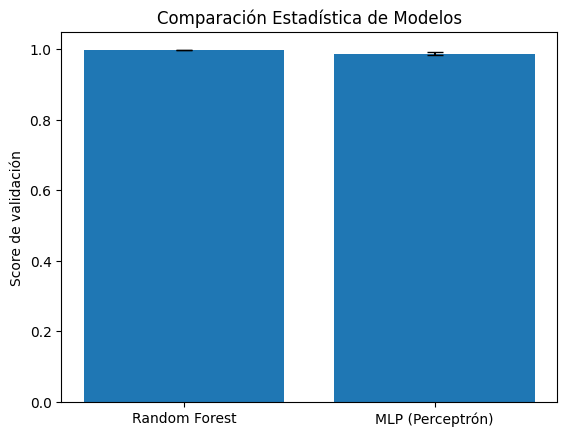

In [48]:
# === 6) Gráfico comparativo ===
x = np.arange(len(tabla))
plt.bar(x, tabla["Media"], yerr=tabla["STD"], capsize=6)
plt.xticks(x, tabla["Modelo"])
plt.ylabel("Score de validación")
plt.title("Comparación Estadística de Modelos")
plt.show()

In [49]:
# === 7) Conclusión automática ===
print("\n=== Conclusión rápida ===")
if rf_media > mlp_media:
    print(f"Random Forest tuvo mejor desempeño promedio ({rf_media:.3f} ± {rf_std:.3f}) "
          f"que MLP ({mlp_media:.3f} ± {mlp_std:.3f}).")
elif mlp_media > rf_media:
    print(f"MLP tuvo mejor desempeño promedio ({mlp_media:.3f} ± {mlp_std:.3f}) "
          f"que Random Forest ({rf_media:.3f} ± {rf_std:.3f}).")
else:
    print(f"Ambos modelos mostraron un desempeño muy similar: {rf_media:.3f}.")


=== Conclusión rápida ===
Random Forest tuvo mejor desempeño promedio (0.998 ± 0.001) que MLP (0.987 ± 0.004).


In [ ]:
#Tabla resumen con media ± desviación estándar de cada modelo.
#Gráfico de barras comparativo con barras de error.